# Insurance Charges Prediction

## Project Overview

The goal of this project is to predict individual medical insurance charges using demographic and health-related information.

The dataset contains information about insurance beneficiaries, including age, sex, body mass index (BMI), number of children, smoking status, and residential region.

The target variable is:

* **charges** – individual medical insurance costs billed by health insurance.

## Dataset Features

* **age** – age of the beneficiary
* **sex** – gender of the beneficiary
* **bmi** – body mass index
* **children** – number of dependents covered by insurance
* **smoker** – smoking status
* **region** – residential area in the United States
* **charges** – medical insurance costs (target variable)

## Project Workflow

1. Data Exploration and Visualization (EDA)
2. Data Preprocessing and Feature Encoding
3. Linear Regression
4. SGD Regressor
5. Polynomial Regression
6. Model Evaluation using MAE, RMSE, and R²
7. Learning Curve Analysis
8. Model Comparison and Conclusions


# Import Libraries

In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import shapiro

# Data preprocessing
from sklearn.preprocessing import (
    StandardScaler,
    PolynomialFeatures
)

# Model selection
from sklearn.model_selection import (
    train_test_split,
    learning_curve
)

# Models
from sklearn.linear_model import (
    LinearRegression,
    SGDRegressor
)

from sklearn.pipeline import make_pipeline

# Evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Load Dataset

In [5]:
# Load the insurance dataset

path = r'insurance.csv'

df = pd.read_csv(path)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Dataset Overview

In [7]:
# Dataset dimensions

df.shape

(1338, 7)

In [8]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
# Summary statistics

df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
# Missing values

df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### Observations

- The dataset contains 1338 observations and 7 variables.
- No missing values were detected.
- The dataset includes both numerical and categorical features.
- The target variable is `charges`, representing medical insurance costs.

# Exploratory Data Analysis (EDA)

## Normality Test

In [14]:
stat, p = shapiro(df['charges'])

print("Statistic:", stat)
print("p-value:", p)

Statistic: 0.8146881157362383
p-value: 1.1505226334932036e-36


The Shapiro-Wilk test was performed to evaluate whether the target variable (`charges`) follows a normal distribution.

- H₀: Data is normally distributed.
- H₁: Data is not normally distributed.

A p-value lower than 0.05 indicates that the null hypothesis should be rejected.

### Interpretation

The obtained p-value (1.15 × 10⁻³⁶) is far below the significance level of 0.05.

Since the p-value is significantly lower than 0.05, the null hypothesis is rejected.

Therefore, there is sufficient evidence to conclude that the target variable (charges) does not follow a normal distribution.

## Distribution of Insurance Charges

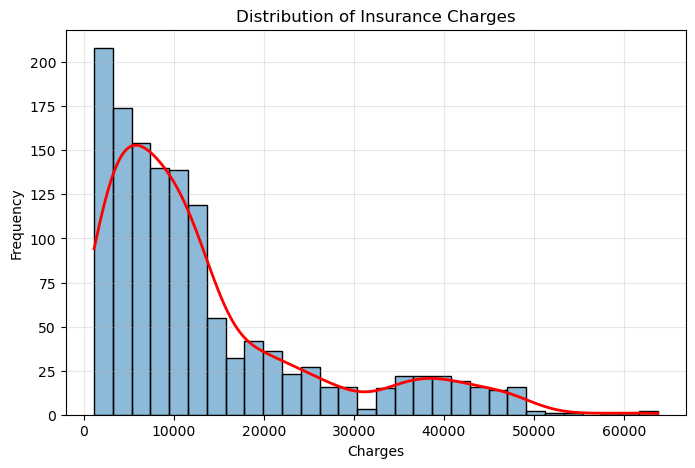

In [17]:
plt.figure(figsize=(8,5))

ax = sns.histplot(
    df['charges'],
    bins=30,
    kde=True
)

ax.lines[0].set_color('red')
ax.lines[0].set_linewidth(2)

plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Insurance Charges')

plt.grid(True, alpha=0.3)

plt.show()

### Interpretation

The histogram shows that the distribution of insurance charges is positively skewed.

Most individuals have relatively low medical expenses, while a smaller number of individuals have very high insurance charges.

This observation is consistent with the Shapiro-Wilk test, which indicated that the target variable does not follow a normal distribution.

## Relationship Between Age and Insurance Charges

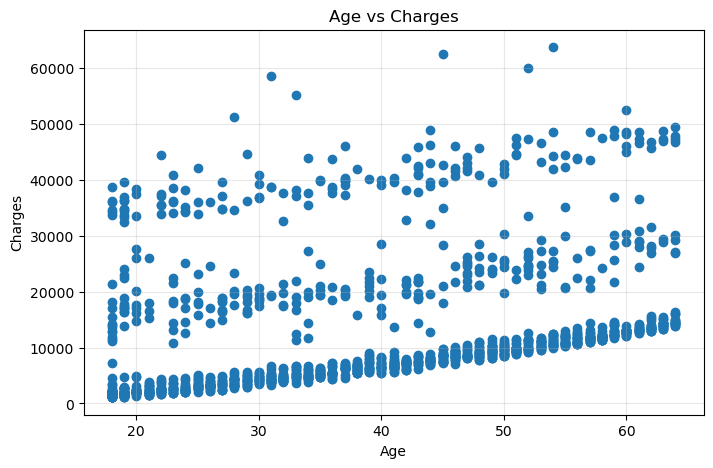

In [26]:
plt.figure(figsize=(8,5))

plt.scatter(df['age'], df['charges'])

plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Age vs Charges')

plt.grid(True, alpha=0.3)

plt.show()

### Interpretation

The scatter plot suggests a positive relationship between age and insurance charges.

In general, older individuals tend to have higher medical insurance costs. However, the relationship is not perfectly linear, and there is considerable variability in charges across all age groups.

## Relationship Between BMI and Insurance Charges

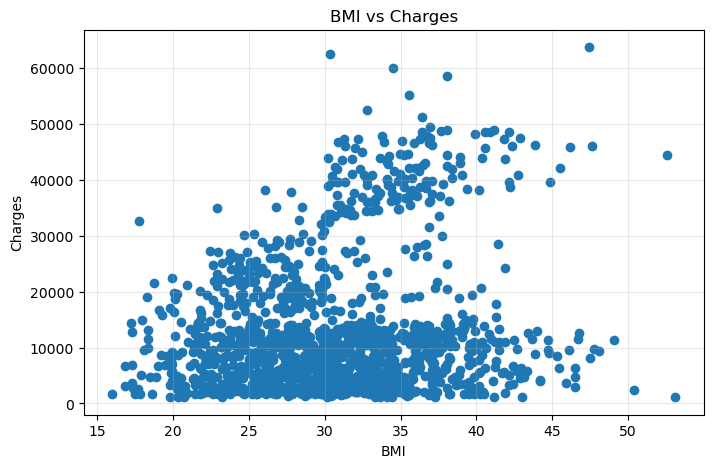

In [31]:
plt.figure(figsize=(8,5))

plt.scatter(df['bmi'], df['charges'])

plt.xlabel('BMI')
plt.ylabel('Charges')
plt.title('BMI vs Charges')

plt.grid(True, alpha=0.3)

plt.show()

### Interpretation

The scatter plot indicates a positive relationship between BMI and insurance charges.

Individuals with higher BMI values tend to have higher medical expenses. However, the relationship appears weaker than the relationship observed between age and insurance charges.

Several observations with very high charges are visible, suggesting that additional factors may influence insurance costs.

## Smoking Status and Insurance Charges

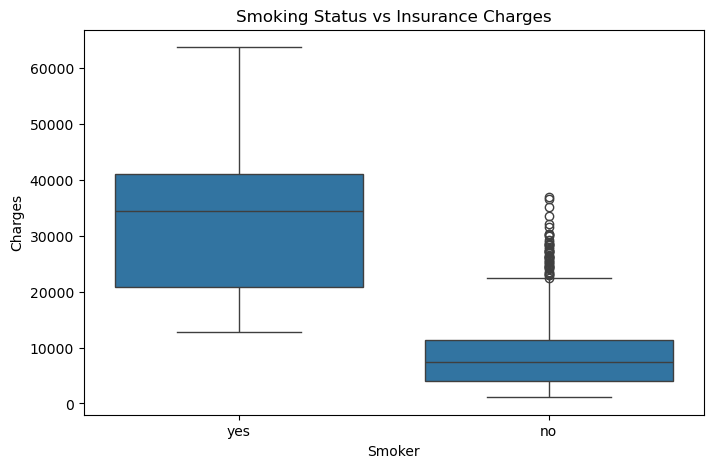

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='smoker',
    y='charges',
    data=df
)

plt.title('Smoking Status vs Insurance Charges')
plt.xlabel('Smoker')
plt.ylabel('Charges')

plt.show()

### Interpretation

The boxplot reveals a substantial difference in insurance charges between smokers and non-smokers.

Smokers tend to have significantly higher medical insurance costs, as indicated by both the higher median and the wider distribution of charges.

This suggests that smoking status is one of the most influential predictors of insurance expenses.

## Categorical Features and Insurance Charges

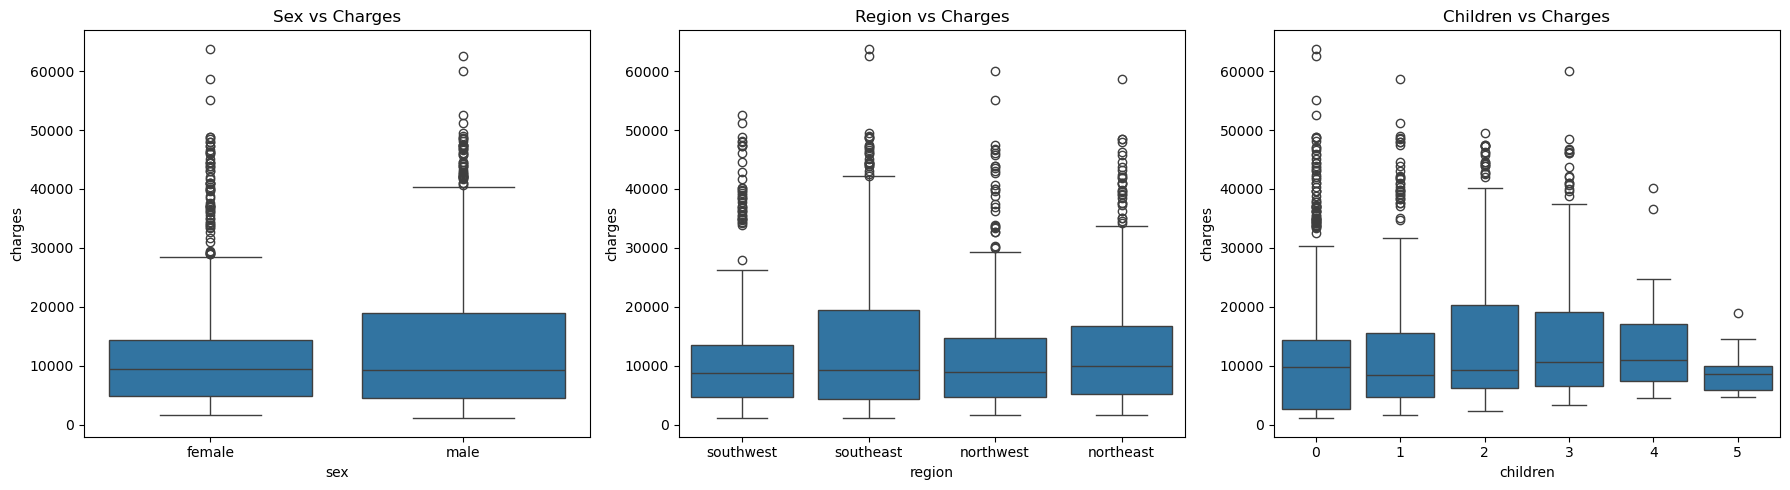

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='sex', y='charges', data=df, ax=axes[0])
axes[0].set_title('Sex vs Charges')

sns.boxplot(x='region', y='charges', data=df, ax=axes[1])
axes[1].set_title('Region vs Charges')

sns.boxplot(x='children', y='charges', data=df, ax=axes[2])
axes[2].set_title('Children vs Charges')

plt.tight_layout()
plt.show()

### Interpretation

The distributions of insurance charges appear relatively similar across regions and sexes, suggesting a limited direct effect on insurance costs.

The number of children shows some variation in charges, although the relationship is less pronounced compared to smoking status.

Overall, these variables appear to have a weaker influence on insurance charges than age, BMI, and smoking status.

# Data Preprocessing

## Encoding Categorical Variables

In [45]:
df_encoded = pd.get_dummies(
    df,
    columns=['sex', 'smoker', 'region'],
    drop_first=True,
    dtype=int
)

### Explanation

Categorical variables cannot be used directly by most machine learning algorithms.

Therefore, one-hot encoding was applied to the following features:

- sex
- smoker
- region

The parameter `drop_first=True` was used to avoid multicollinearity by removing one category from each encoded feature.

In [48]:
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


## Correlation Analysis

In [51]:
corr_matrix = df_encoded.corr()

corr_matrix['charges'].sort_values(ascending=False)

charges             1.000000
smoker_yes          0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex_male            0.057292
region_northwest   -0.039905
region_southwest   -0.043210
Name: charges, dtype: float64

### Interpretation

The strongest positive correlation with insurance charges was observed for smoking status, indicating that smokers tend to have significantly higher medical expenses.

Age and BMI also showed positive correlations with insurance charges, suggesting that older individuals and those with higher BMI values generally incur higher medical costs.

Some variables exhibited weak correlations, indicating a limited direct linear relationship with the target variable.

### Correlation Matrix Visualization

To better understand the relationships between variables, a correlation heatmap was generated. The heatmap provides a visual representation of the strength and direction of correlations between all features and the target variable.

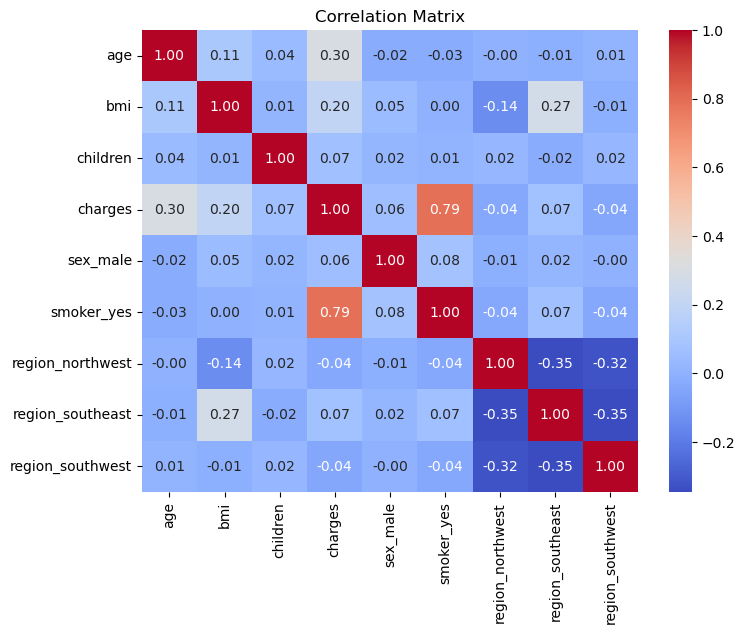

In [55]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

### Interpretation

The heatmap confirms the findings from the previous analysis.

- Smoking status exhibits the strongest positive correlation with insurance charges.
- Age and BMI show moderate positive correlations with the target variable.
- Sex and region have relatively weak correlations with insurance charges.
- Several predictor variables show low mutual correlations, suggesting limited multicollinearity within the dataset.

These observations support the inclusion of all available features in the subsequent machine learning models.

# Feature Selection and Train-Test Split

## Feature and Target Definition

Before training machine learning models, the dataset was divided into:

- Features (X): predictor variables used for model training.
- Target (y): insurance charges to be predicted.

In [60]:
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

### Explanation

The target variable (`charges`) was separated from the predictor variables.

The resulting feature matrix `X` contains all input variables, while `y` contains the insurance charges that the models will learn to predict.

## Train-Test Split

The dataset was divided into training and testing subsets.

- 80% of the data was used for training.
- 20% of the data was reserved for testing.

The random state was fixed to ensure reproducibility of the results.

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [66]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1070, 8)
X_test shape: (268, 8)
y_train shape: (1070,)
y_test shape: (268,)


# Machine Learning Models

## Linear Regression

### Model Training

A Linear Regression model was trained using the training dataset. The model learns the relationship between the predictor variables and insurance charges by minimizing the residual sum of squares.

In [69]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

### Explanation

The `fit()` method estimates the regression coefficients using the training data.

Once trained, the model can be used to predict insurance charges for previously unseen observations.

### Feature Importance (Model Coefficients)

In [73]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear_model.coef_
})

coef_df.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

,Feature,Coefficient
4,smoker_yes,23651.128856
7,region_southwest,-809.799354
6,region_southeast,-657.864297
2,children,425.278784
5,region_northwest,-370.677326
1,bmi,337.092552
0,age,256.975706
3,sex_male,-18.591692


### Interpretation

The coefficients indicate how each feature influences the predicted insurance charges.

- Positive coefficients increase the predicted charges.
- Negative coefficients decrease the predicted charges.
- Features with larger absolute coefficient values have a stronger impact on the prediction.

It is important to note that coefficient magnitude should be interpreted carefully because the features are measured on different scales.

### Model Evaluation

In [77]:
y_pred = linear_model.predict(X_test) 

In [79]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 4181.1944737536505
RMSE: 5796.284659276272
R²: 0.7835929767120724


### Interpretation

The Linear Regression model achieved an R² score of approximately 0.78, indicating that around 78% of the variance in insurance charges can be explained by the predictor variables.

The MAE and RMSE values suggest that the model provides a reasonable baseline performance, although some prediction errors remain due to nonlinear relationships within the dataset.

### Actual vs Predicted Values

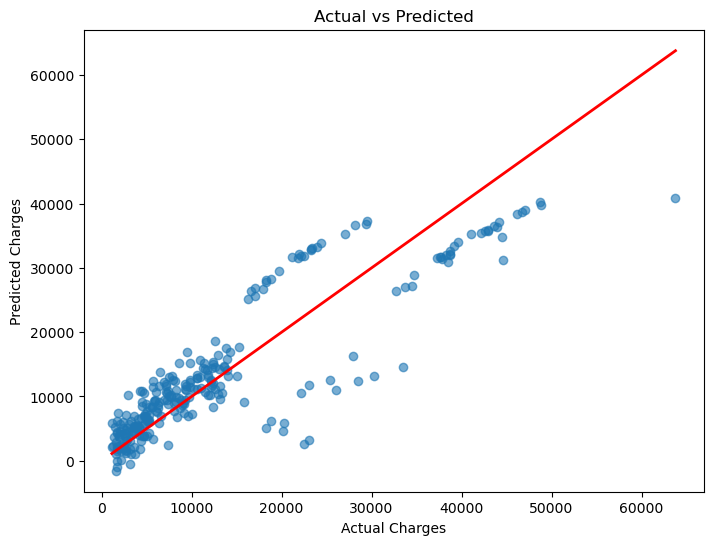

In [83]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")

plt.show()

### Interpretation

The scatter plot compares actual insurance charges with the values predicted by the Linear Regression model.

If predictions were perfect, all points would lie exactly on the red diagonal line.

Most observations are located close to the reference line, indicating that the model captures a substantial portion of the variability in insurance charges. However, noticeable deviations remain, particularly for observations with very high charges.

### Residual Plot

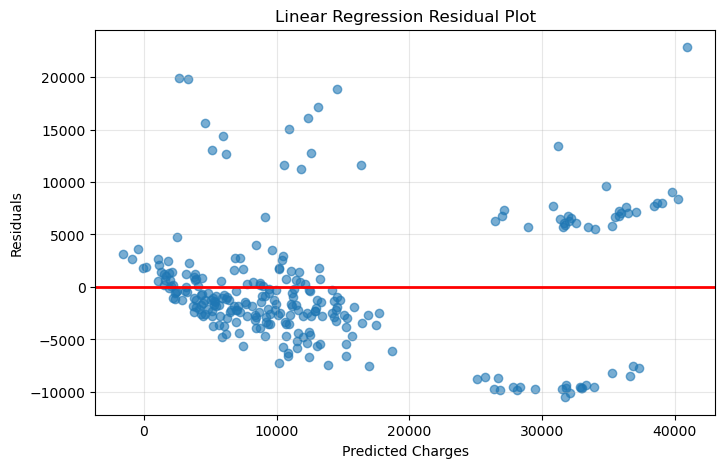

In [87]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linewidth=2)

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Linear Regression Residual Plot")

plt.grid(True, alpha=0.3)

plt.show()

### Interpretation

The residual plot shows the difference between actual and predicted insurance charges.

Ideally, residuals should be randomly distributed around zero.

In this case, some visible patterns and large residuals remain, suggesting that the Linear Regression model does not fully capture the nonlinear structure of the data.

## SGDRegressor 

### Model Training

An SGD Regressor was trained to compare its performance with the standard Linear Regression model.

Because SGD is sensitive to feature scales, standardization was applied before training.

In [91]:
sgd_reg = make_pipeline(
    StandardScaler(),
    SGDRegressor(
        max_iter=5000,
        tol=1e-5,
        penalty=None,
        random_state=42
    )
)

sgd_reg.fit(X_train, y_train)

y_pred_sgd = sgd_reg.predict(X_test) 

### Explanation

The pipeline consists of two steps:

1. StandardScaler – standardizes the input features.
2. SGDRegressor – trains a linear regression model using Stochastic Gradient Descent.

Unlike Linear Regression, which computes the optimal coefficients analytically, SGDRegressor learns the coefficients iteratively through optimization.

### Model Evaluation

In [95]:
mae_sgd = mean_absolute_error(y_test, y_pred_sgd)
rmse_sgd = mean_squared_error(y_test, y_pred_sgd) ** 0.5
r2_sgd = r2_score(y_test, y_pred_sgd)

print("MAE:", mae_sgd)
print("RMSE:", rmse_sgd)
print("R²:", r2_sgd)

MAE: 4172.320831251898
RMSE: 5797.252997033396
R²: 0.7835206639778982


## Polynomial Regression 

### Feature Expansion and Model Training

Polynomial features were generated to capture nonlinear relationships between predictor variables and insurance charges.

A Linear Regression model was then trained on the expanded feature set.

In [98]:
poly_features = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_poly = poly_features.fit_transform(X_train)

poly_model = LinearRegression()

poly_model.fit(X_poly, y_train)

X_test_poly = poly_features.transform(X_test)

y_pred_poly = poly_model.predict(X_test_poly)

### Explanation

PolynomialFeatures expands the original feature set by creating squared terms and interaction terms.

For example:

- age → age²
- bmi → bmi²
- age × bmi

This allows a linear model to learn nonlinear relationships without changing the underlying regression algorithm.

### Model Evaluation

In [102]:
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = mean_squared_error(y_test, y_pred_poly) ** 0.5
r2_poly = r2_score(y_test, y_pred_poly)

print("MAE:", mae_poly)
print("RMSE:", rmse_poly)
print("R²:", r2_poly)

MAE: 2729.500133639454
RMSE: 4551.132385233216
R²: 0.8665830903164826


### Actual vs Predicted Values

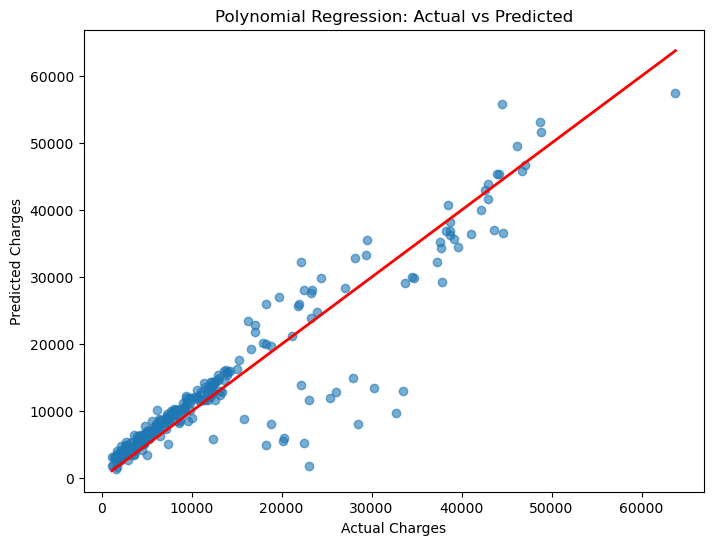

In [105]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_poly, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r-',
    linewidth=2
)

plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Polynomial Regression: Actual vs Predicted')

plt.show()

### Interpretation

The scatter plot shows a stronger alignment between actual and predicted values compared to the Linear Regression model.

Most observations are concentrated around the diagonal reference line, indicating improved predictive performance.

This visual improvement is consistent with the higher R² score achieved by the Polynomial Regression model.

### Residual Plot

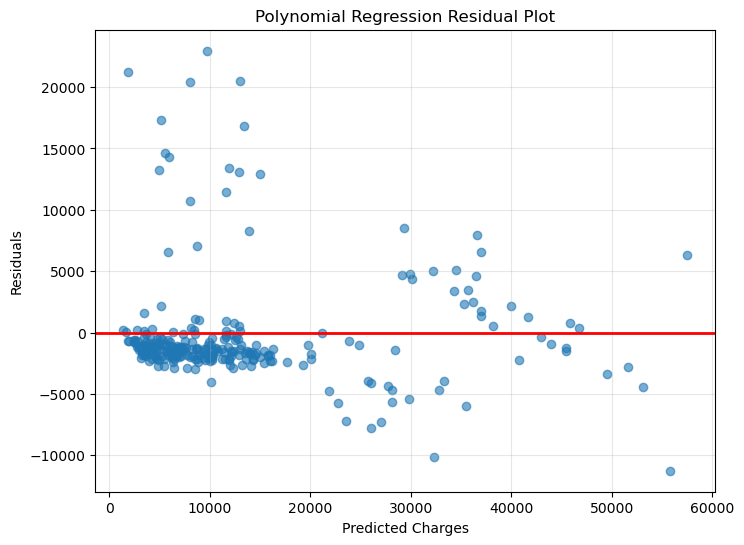

In [109]:
residuals_poly = y_test - y_pred_poly

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_poly,
    residuals_poly,
    alpha=0.6
)

plt.axhline(
    y=0,
    color='red',
    linewidth=2
)

plt.xlabel('Predicted Charges')
plt.ylabel('Residuals')
plt.title('Polynomial Regression Residual Plot')

plt.grid(True, alpha=0.3)

plt.show()

### Interpretation

The residuals are distributed more evenly around zero compared to the Linear Regression model.

No strong systematic pattern is visible, suggesting that Polynomial Regression captures nonlinear relationships more effectively.

Although some large residuals remain, the overall distribution indicates improved model performance and better generalization.

## Model Comparison

### Comparison of Model Performance

To compare the predictive performance of all trained models, MAE, RMSE, and R² metrics were summarized in a single table.

In [113]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'SGD Regressor', 'Polynomial Regression'],
    'MAE': [mae, mae_sgd, mae_poly],
    'RMSE': [rmse, rmse_sgd, rmse_poly],
    'R2': [r2, r2_sgd, r2_poly]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,4181.194474,5796.284659,0.783593
1,SGD Regressor,4172.320831,5797.252997,0.783521
2,Polynomial Regression,2729.500134,4551.132385,0.866583


### Interpretation

Linear Regression and SGD Regressor achieved nearly identical performance, indicating that both models learned a similar linear relationship between the features and insurance charges.

Polynomial Regression outperformed both models by achieving the lowest MAE and RMSE values, as well as the highest R² score.

This improvement suggests that nonlinear relationships exist within the dataset and can be captured effectively through polynomial feature expansion.

# Learning Curve Analysis

In [117]:
polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
) 

## Polynomial Regression Learning Curves

Learning curves were used to evaluate how model performance changes as the training set size increases.

The training and validation errors were measured using RMSE through 5-fold cross-validation.

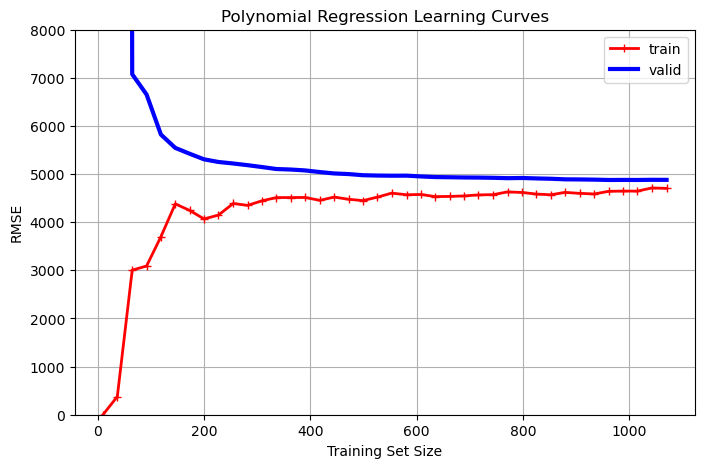

In [120]:
train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression,
    X,
    y,
    train_sizes=np.linspace(0.01, 1.0, 40),
    cv=5,
    scoring="neg_root_mean_squared_error"
)

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_errors,
    "r-+",
    linewidth=2,
    label="train"
)

plt.plot(
    train_sizes,
    valid_errors,
    "b-",
    linewidth=3,
    label="valid"
)

plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.title("Polynomial Regression Learning Curves")
plt.grid(True)
plt.legend()

plt.ylim(0, 8000)

plt.show()

### Interpretation

The training and validation errors gradually converge as the training set size increases.

The relatively small gap between the curves suggests that the model generalizes reasonably well and does not exhibit severe overfitting.

The validation error stabilizes at a lower level than the Linear Regression model, indicating that Polynomial Regression captures additional nonlinear relationships present in the dataset.

# Conclusion

Three regression models were evaluated for predicting insurance charges:

- Linear Regression
- SGD Regressor
- Polynomial Regression

Linear Regression and SGD Regressor achieved similar performance, with an R² score of approximately 0.78.

Polynomial Regression significantly improved performance, achieving an R² score of 0.87 while reducing both MAE and RMSE.

Learning curves indicated that Linear Regression underfits the data, while Polynomial Regression captures nonlinear relationships more effectively and generalizes well.

Overall, Polynomial Regression was the best-performing model for this dataset.